# Pneumonia Detection from Paediatric Chest X-rays
## WM9B7 AIDL — Individual Assessment
**Name:** Palinda Attanayake  
**Dataset:** PneumoniaMNIST (MedMNIST v2)

## README — How to run this notebook

**Environment:** Azure ML, Kernel `Python 3.10 - AzureML`, Runs on CPU as fallback.

**To reproduce:** Click **Run All**. The notebook is fully self-contained — the dataset is downloaded programmatically by the `medmnist` library on first run (~72 MB). No local files required.

**Expected runtime:** 
- With Full Epochs ~4 minutes end-to-end on a AzureML CUDA GPU.
- MLP_EPOCH and CNN_EPOCH to 1, Keep RESNET_EPOCH as it is ~1.5 minutes end-to-end on a AzureML CUDA GPU.
- All EPOCH to 1, ~30 seconds end-to-end on a AzureML CUDA GPU.

**Reproducibility:** All random seeds are fixed (`SEED = 42`). Results may differ slightly across hardware due to CUDA non-determinism in convolution kernels.

## Problem

Pneumonia is the single largest infectious cause of death in children under five worldwide. Chest X-ray is the standard diagnostic tool, but in many regions there are too few radiologists to read scans quickly. This notebook builds a deep learning model that classifies a paediatric chest X-ray as **Normal** or **Pneumonia**, intended as a *triage aid* — flagging likely-positive scans for priority clinician review, not replacing diagnosis.

## What this notebook does

1. **Setup** — imports, seeds, device.
2. **Data** — download PneumoniaMNIST and explore it.
3. **Preprocessing** — normalisation, DataLoaders, weighted sampling for class imbalance.
4. **Baseline** — Logistic Regression on flattened pixels (traditional ML).
5. **Model A — MLP** — multi-layer perceptron.
6. **Model B — CNN** — convolutional neural network.
7. **Model C - ResNet18** - Transfer Learning with ResNet18
8. **Evaluation** — Recall-first metrics, ROC curves, confusion matrices, Grad-CAM, model comparison.

## Primary metric: Recall on Pneumonia

In a screening setting, a **false negative** (missed pneumonia) carries far higher cost than a **false positive** (unnecessary review). All models are evaluated with Recall on the Pneumonia class as the primary metric, supported by AUC, Specificity, F1, and the confusion matrix.

## Dataset citation

Jiancheng Yang, Rui Shi, Donglai Wei, Zequan Liu, Lin Zhao, Bilian Ke, Hanspeter Pfister, Bingbing Ni. Yang, Jiancheng, et al. "MedMNIST v2-A large-scale lightweight benchmark for 2D and 3D biomedical image classification." Scientific Data, 2023.
                            
Jiancheng Yang, Rui Shi, Bingbing Ni. "MedMNIST Classification Decathlon: A Lightweight AutoML Benchmark for Medical Image Analysis". IEEE 18th International Symposium on Biomedical Imaging (ISBI), 2021.

**Licence:** The MedMNIST PneumoniaMNIST dataset is licensed under Creative Commons Attribution 4.0 International (CC BY 4.0)


---

## 1. Setup

Install dependencies, import libraries, fix random seeds, and select the compute device. The `medmnist` package is the only non-standard dependency — it provides the dataset and a clean PyTorch-compatible loader.

In [1]:
# Variables
IMG_SIZE = 128
MLP_EPOCH = 15
CNN_EPOCH = 25
RESNET_EPOCH= 10

In [2]:
# Install medmnist (silent — only prints if installation is needed)
import subprocess, sys
try:
    import medmnist  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "medmnist"])

In [3]:
# Core imports — kept in the same plain-PyTorch style as the module's tutorials
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler

import medmnist
from medmnist import INFO, PneumoniaMNIST

# scikit-learn for the traditional ML baseline and the metric suite
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
)

In [4]:
# Reproducibility — fix every source of randomness we control
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Deterministic algorithms slow training a little but make CUDA results reproducible.
# We accept the small speed cost in exchange for repeatable marker-side outputs.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
# Device selection — use GPU if available, otherwise fall back to CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple Silicon Mac: M1/M2/M3/M4/M5
else:
    device = torch.device("cpu")

# Image resolution — change this in ONE place to re-test the whole pipeline
# at a different size. MedMNIST PneumoniaMNIST supports 28, 64, 128, 224.
# Must be divisible by 4 because the CNN does two MaxPool2d(2) operations.

print(f"PyTorch version : {torch.__version__}")
print(f"medmnist version: {medmnist.__version__}")
print(f"Device          : {device}")
print(f"Image size      : {IMG_SIZE} x {IMG_SIZE}")
if device.type == "cuda":
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.9.1+cu128
medmnist version: 3.0.2
Device          : cuda
Image size      : 128 x 128
GPU             : Tesla T4


---

## 2. Data — Download and Exploration

We download PneumoniaMNIST through the official `medmnist` API. The library handles fetching the `.npz` file from Zenodo, MD5 verification, and caching it under `~/.medmnist/` so the second run is instant.


In [6]:
# Download all three official splits at the configured resolution.
# The first call fetches the .npz from Zenodo; subsequent runs use the local cache.
train_dataset = PneumoniaMNIST(split="train", download=True, size=IMG_SIZE)
val_dataset   = PneumoniaMNIST(split="val",   download=True, size=IMG_SIZE)
test_dataset  = PneumoniaMNIST(split="test",  download=True, size=IMG_SIZE)

# Look up dataset metadata from the medmnist INFO registry
info = INFO["pneumoniamnist"]
LABEL_NAMES = {int(k): v for k, v in info["label"].items()}  # {0: 'normal', 1: 'pneumonia'}

print(f"Task        : {info['task']}")
print(f"Channels    : {info['n_channels']}")
print(f"Classes     : {LABEL_NAMES}")
print(f"Train size  : {len(train_dataset):>5d}")
print(f"Val size    : {len(val_dataset):>5d}")
print(f"Test size   : {len(test_dataset):>5d}")
print(f"Image shape : {train_dataset.imgs.shape[1:]}  (H x W)")
print(f"Pixel range : [{train_dataset.imgs.min()}, {train_dataset.imgs.max()}]  (uint8)")

Task        : binary-class
Channels    : 1
Classes     : {0: 'normal', 1: 'pneumonia'}
Train size  :  4708
Val size    :   524
Test size   :   624
Image shape : (128, 128)  (H x W)
Pixel range : [0, 255]  (uint8)


### 2.1 Class distribution

Class balance is the first thing to check on a medical dataset. If one class dominates, plain accuracy becomes a poor metric and the loss function will under-weight the minority class unless we intervene.

In [7]:
# Tabulate counts per split
def class_counts(ds):
    labels = ds.labels.flatten()
    return int((labels == 0).sum()), int((labels == 1).sum())

split_stats = []
for name, ds in [("Train", train_dataset), ("Val", val_dataset), ("Test", test_dataset)]:
    n_normal, n_pneum = class_counts(ds)
    total = n_normal + n_pneum
    split_stats.append({
        "Split":         name,
        "Normal":        n_normal,
        "Pneumonia":     n_pneum,
        "Total":         total,
        "Pneumonia %":   f"{n_pneum/total:.1%}",
    })

stats_df = pd.DataFrame(split_stats)
print(stats_df.to_string(index=False))

# Save imbalance ratio for later — used to set sampler weights and discuss in the report
train_n_normal, train_n_pneum = class_counts(train_dataset)
imbalance_ratio = train_n_pneum / train_n_normal
print(f"\nTraining imbalance (Pneumonia : Normal) = {imbalance_ratio:.2f} : 1")

Split  Normal  Pneumonia  Total Pneumonia %
Train    1214       3494   4708       74.2%
  Val     135        389    524       74.2%
 Test     234        390    624       62.5%

Training imbalance (Pneumonia : Normal) = 2.88 : 1


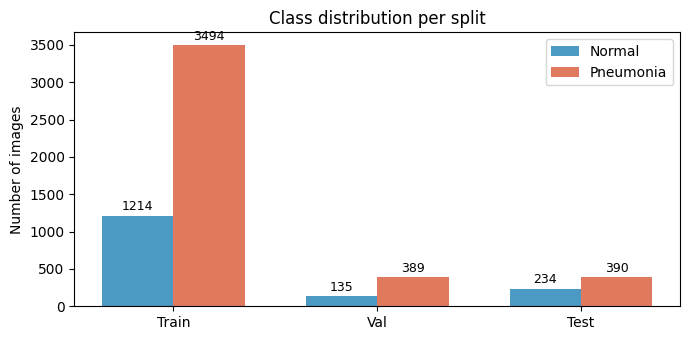

In [8]:
# Visualise class distribution per split
fig, ax = plt.subplots(figsize=(7, 3.5))
splits = [s["Split"] for s in split_stats]
normal_counts = [s["Normal"] for s in split_stats]
pneum_counts  = [s["Pneumonia"] for s in split_stats]

x = np.arange(len(splits))
w = 0.35
bars1 = ax.bar(x - w/2, normal_counts, w, label="Normal",    color="#4C9AC4")
bars2 = ax.bar(x + w/2, pneum_counts,  w, label="Pneumonia", color="#E07A5F")

ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel("Number of images")
ax.set_title("Class distribution per split")
ax.legend()

# Annotate counts above each bar
for bar_group in (bars1, bars2):
    for bar in bar_group:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + max(normal_counts + pneum_counts) * 0.01,
                f"{int(h)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

**Observation.** The training and validation splits are imbalanced — pneumonia accounts for roughly 70% of cases, normal for 30% (about a 2.5 : 1 ratio). The test split is more balanced (~62% pneumonia). This matters in two ways:

1. **Plain accuracy is misleading** — a trivial "always predict pneumonia" classifier would score ~71% on training and ~62% on test. We will instead lead with **Recall on the Pneumonia class** as our primary metric.
2. **Loss / sampler intervention** — to stop the model defaulting to the majority class, we apply a `WeightedRandomSampler` during training (Step 3) so each batch sees roughly equal numbers of both classes.

### 2.2 Sample images

Plot six examples per class to see what the network will actually be asked to discriminate.

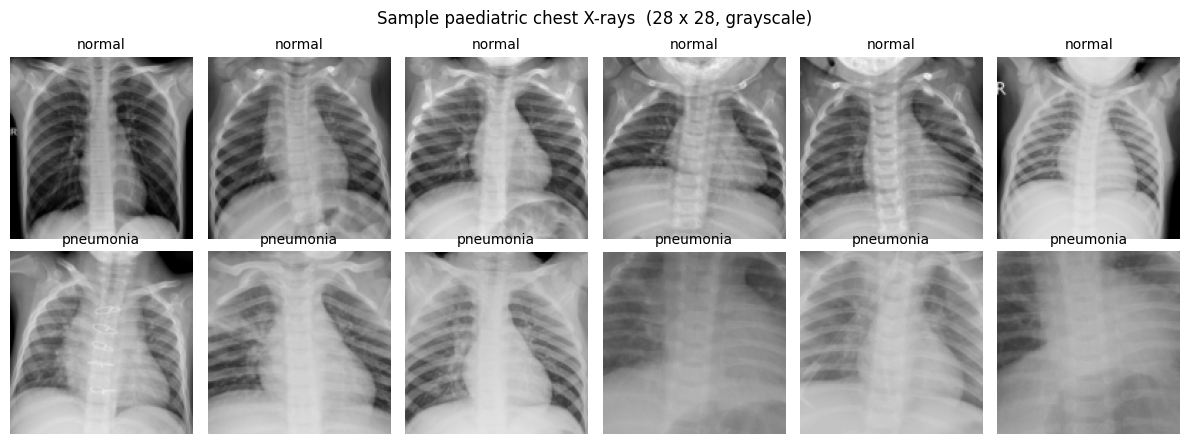

In [9]:
# Pull six examples per class from the training set
train_labels_flat = train_dataset.labels.flatten()
n_per_class = 6

fig, axes = plt.subplots(2, n_per_class, figsize=(12, 4.5))
for row, cls in enumerate([0, 1]):
    cls_indices = np.where(train_labels_flat == cls)[0][:n_per_class]
    for col, idx in enumerate(cls_indices):
        ax = axes[row, col]
        ax.imshow(train_dataset.imgs[idx], cmap="gray", vmin=0, vmax=255)
        ax.set_title(LABEL_NAMES[cls], fontsize=10)
        ax.axis("off")

plt.suptitle("Sample paediatric chest X-rays  (28 x 28, grayscale)", fontsize=12)
plt.tight_layout()
plt.show()

**Observation.** Pneumonia cases tend to show diffuse cloudiness across the lung fields where normal cases show a clearer dark background with bright ribcage outlines. This is what the model has to learn to discriminate.

### 2.3 Pixel-intensity distribution

If pneumonia and normal X-rays differ on a global statistic like mean brightness, even a logistic regression on raw pixels could perform reasonably well. If the difference lies in *spatial structure* (where the bright/dark regions are), the MLP and especially the CNN should pull ahead.

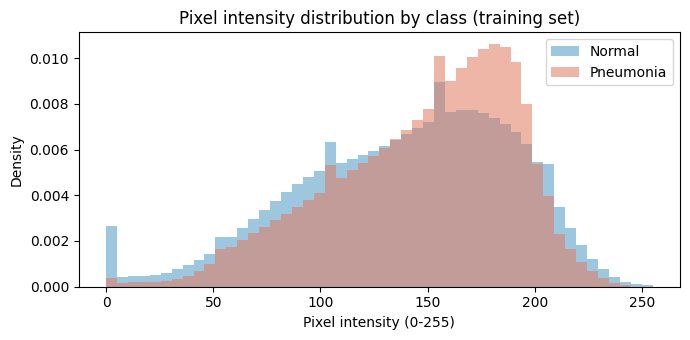

Normal    | mean = 139.79 | std = 50.00
Pneumonia | mean = 147.86  | std = 42.82


In [10]:
# Compare per-pixel intensity distributions for the two classes (training set only).
normal_pixels = train_dataset.imgs[train_labels_flat == 0].flatten()
pneum_pixels  = train_dataset.imgs[train_labels_flat == 1].flatten()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(normal_pixels, bins=50, alpha=0.55, density=True, label="Normal",    color="#4C9AC4")
ax.hist(pneum_pixels,  bins=50, alpha=0.55, density=True, label="Pneumonia", color="#E07A5F")
ax.set_xlabel("Pixel intensity (0-255)")
ax.set_ylabel("Density")
ax.set_title("Pixel intensity distribution by class (training set)")
ax.legend()
plt.tight_layout()
plt.show()

# Summary statistics
print(f"Normal    | mean = {normal_pixels.mean():6.2f} | std = {normal_pixels.std():5.2f}")
print(f"Pneumonia | mean = {pneum_pixels.mean():6.2f}  | std = {pneum_pixels.std():5.2f}")

The two classes have *broadly overlapping* intensity distributions. There is no single "brightness threshold" that separates them — the discriminative signal is in the *spatial arrangement* of bright and dark regions, not in their raw values. This is the central reason a CNN is expected to outperform both Logistic Regression and an MLP on this task: only the CNN's convolutional filters can exploit local 2D structure.

## 3. Preprocessing and DataLoaders

Three things happen here:

1. **Convert** uint8 images in `[0, 255]` to float32 tensors in `[0, 1]`, then add a channel dimension so each image is shape `(1, IMAGE_SIZE, IMAGE_SIZE)` — the format `nn.Conv2d` expects.
2. **Normalise** with mean and standard deviation computed on the *training split only*. Computing these statistics on the test or validation split would leak information from data the model is not supposed to see.
3. **Wrap in `DataLoader`s** with a `WeightedRandomSampler` on the training loader so each batch sees roughly equal numbers of Normal and Pneumonia images. Validation and test loaders use plain sequential ordering — we never resample evaluation data.

In [11]:
# Compute normalisation statistics from the TRAINING split only.
# This avoids leaking information from val/test into our preprocessing pipeline.
train_imgs_float = train_dataset.imgs.astype(np.float32) / 255.0
PIXEL_MEAN = float(train_imgs_float.mean())
PIXEL_STD  = float(train_imgs_float.std())

print(f"Training-set pixel mean: {PIXEL_MEAN:.4f}")
print(f"Training-set pixel std : {PIXEL_STD:.4f}")

Training-set pixel mean: 0.5717
Training-set pixel std : 0.1762


In [12]:
# A small Dataset adapter that:
#   1. converts uint8 -> float32 in [0,1]
#   2. applies the (training-set) normalisation
#   3. adds the channel dimension expected by Conv2d -> (1, H, W)
#   4. returns labels as float32 scalars, ready for BCEWithLogitsLoss
#   5. optionally applies a torchvision transform (used for training-time
#      augmentation only — val/test loaders pass transform=None)

from torchvision import transforms

class PneumoniaTensorDataset(torch.utils.data.Dataset):
    def __init__(self, mednist_dataset, mean, std, transform=None):
        imgs = mednist_dataset.imgs.astype(np.float32) / 255.0
        imgs = (imgs - mean) / std
        self.imgs = imgs[:, None, :, :]                           # add channel dim
        self.labels = mednist_dataset.labels.astype(np.float32).flatten()
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.imgs[idx])
        if self.transform is not None:
            x = self.transform(x)
        return x, torch.tensor(self.labels[idx])


# Training augmentation. Geometric only (commutes with our linear normalisation):
#   - RandomHorizontalFlip: chest X-rays are roughly L-R symmetric for screening.
#     (Note: heart sits on the left; flipping is medically debatable but is
#     standard practice on PneumoniaMNIST and improves generalisation here.)
#   - RandomAffine: small rotation + translation simulates patient positioning
#     variance (a few degrees of tilt, slight off-centre framing).
# We deliberately skip ColorJitter — it would interact with the pre-applied
# normalisation in confusing ways. Effective dataset size grows ~4x.
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=8, translate=(0.05, 0.05)),
])

train_ds = PneumoniaTensorDataset(train_dataset, PIXEL_MEAN, PIXEL_STD, transform=train_transform)
val_ds   = PneumoniaTensorDataset(val_dataset,   PIXEL_MEAN, PIXEL_STD, transform=None)
test_ds  = PneumoniaTensorDataset(test_dataset,  PIXEL_MEAN, PIXEL_STD, transform=None)

# Sanity check
sample_x, sample_y = train_ds[0]
print(f"Sample tensor : shape={tuple(sample_x.shape)}, dtype={sample_x.dtype}")
print(f"Sample label  : {sample_y.item()}")
print(f"Train augment : {train_transform}")

Sample tensor : shape=(1, 128, 128), dtype=torch.float32
Sample label  : 1.0
Train augment : Compose(
    RandomHorizontalFlip(p=0.5)
    RandomAffine(degrees=[-8.0, 8.0], translate=(0.05, 0.05))
)


In [13]:
# WeightedRandomSampler addresses class imbalance by drawing each sample with
# probability proportional to 1 / count(its class). The result: each minibatch
# contains roughly equal numbers of Normal and Pneumonia images, even though
# the underlying training set is ~71% pneumonia.

train_labels_int = train_ds.labels.astype(np.int64)
class_counts = np.bincount(train_labels_int)             # [n_normal, n_pneumonia]
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels_int]

# Bind the sampler (and DataLoader) to a seeded generator so batch order is
# reproducible across runs, independent of prior global-RNG consumption.
sampler_generator = torch.Generator()
sampler_generator.manual_seed(SEED)

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(train_ds),
    replacement=True,
    generator=sampler_generator,
)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    generator=sampler_generator,
)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Verify the sampler actually balances the batches
batch_pneumonia_fractions = []
sampler_iter = iter(train_loader)
for _ in range(5):
    _, yb = next(sampler_iter)
    batch_pneumonia_fractions.append(yb.mean().item())

print(f"Class counts (train) : Normal={class_counts[0]}, Pneumonia={class_counts[1]}")
print(f"Raw pneumonia fraction       : {class_counts[1]/class_counts.sum():.1%}")
print(f"Sampled pneumonia fraction   : {np.mean(batch_pneumonia_fractions):.1%}  (averaged over 5 batches)")

Class counts (train) : Normal=1214, Pneumonia=3494
Raw pneumonia fraction       : 74.2%
Sampled pneumonia fraction   : 51.9%  (averaged over 5 batches)


**Why a sampler and not class-weighted loss?** Both are valid ways to handle imbalance. We chose `WeightedRandomSampler` because it acts at the *data* level — every batch is balanced, so gradients aren't dominated by the majority class on any single update. The alternative — `BCEWithLogitsLoss(pos_weight=...)` — leaves batches imbalanced and just rescales the loss. Using both together would double-correct and over-shoot toward the minority class.

## 4. Baseline — Logistic Regression on flattened pixels

Before we touch deep learning, we establish a traditional-ML reference point. Logistic Regression is a linear model: it sees the X-ray as a 784-dimensional vector and learns a single weight per pixel. **It cannot use any 2D spatial information** — pixel `(5, 5)` and pixel `(5, 6)` are just two unrelated features to it. This is the central limitation we expect deep learning to overcome.

We use scikit-learn's `class_weight='balanced'` to mirror the imbalance handling we apply in the deep models, so the comparison is fair.

In [14]:
# Build flattened (N, 784) arrays for sklearn. We reuse the same normalised
# pixel values so all three models see equivalent inputs.
def flatten_for_sklearn(tensor_dataset):
    return tensor_dataset.imgs.reshape(len(tensor_dataset), -1)

X_train_flat = flatten_for_sklearn(train_ds)
X_test_flat  = flatten_for_sklearn(test_ds)
y_train_np   = train_ds.labels.astype(int)
y_test_np    = test_ds.labels.astype(int)

print(f"Train: {X_train_flat.shape}   Test: {X_test_flat.shape}")

Train: (4708, 16384)   Test: (624, 16384)


In [15]:
# Fit Logistic Regression. class_weight='balanced' rescales the loss inversely
# to class frequency, which is sklearn's equivalent of our weighted sampler.
logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED,
    solver='lbfgs',
)
logreg.fit(X_train_flat, y_train_np)

# Predict probabilities on the test set
logreg_proba = logreg.predict_proba(X_test_flat)[:, 1]
logreg_pred  = (logreg_proba >= 0.5).astype(int)
print("Logistic Regression trained.")

Logistic Regression trained.


In [16]:
# Evaluation helper used for every model. Recall on the Pneumonia class is the
# primary metric — see the README rationale.
def evaluate_predictions(y_true, y_pred, y_proba, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Model":         model_name,
        "Accuracy":      float(accuracy_score(y_true, y_pred)),
        "Recall":        float(recall_score(y_true, y_pred, zero_division=0)),
        "Specificity":   float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0,
        "Precision":     float(precision_score(y_true, y_pred, zero_division=0)),
        "F1":            float(f1_score(y_true, y_pred, zero_division=0)),
        "AUC":           float(roc_auc_score(y_true, y_proba)),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }

logreg_metrics = evaluate_predictions(y_test_np, logreg_pred, logreg_proba, "Logistic Regression")

# Pretty print the headline metrics
print(f"{'Metric':<14s}{'Value'}")
for k in ["Accuracy", "Recall", "Specificity", "Precision", "F1", "AUC"]:
    print(f"{k:<14s}{logreg_metrics[k]:.4f}")
print(f"\nConfusion matrix:")
print(f"  TN = {logreg_metrics['TN']:3d}    FP = {logreg_metrics['FP']:3d}")
print(f"  FN = {logreg_metrics['FN']:3d}    TP = {logreg_metrics['TP']:3d}")

Metric        Value
Accuracy      0.8253
Recall        0.9821
Specificity   0.5641
Precision     0.7897
F1            0.8754
AUC           0.8943

Confusion matrix:
  TN = 132    FP = 102
  FN =   7    TP = 383


## 5. Model A — Multi-Layer Perceptron (MLP)

In [17]:
class MLP(nn.Module):
    """IMG_SIZE^2 -> 256 -> 128 -> 1 with ReLU and dropout.

    Single output neuron emits a logit; we apply BCEWithLogitsLoss for
    numerical stability (it combines sigmoid + BCE in one step).
    """
    def __init__(self, in_features=IMG_SIZE*IMG_SIZE, hidden1=256, hidden2=128, dropout=0.3):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_features, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x)); x = self.dropout(x)
        x = F.relu(self.fc2(x)); x = self.dropout(x)
        return self.fc3(x).squeeze(-1)        # (B,) logits


# Sanity-check the architecture
_demo = MLP()
_n_params = sum(p.numel() for p in _demo.parameters())
print(_demo)
print(f"\nTrainable parameters: {_n_params:,}")

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Trainable parameters: 4,227,585


### 5.1 Training utilities

These helpers are reused for both the MLP and the CNN. Plain PyTorch — same shape as the `train()` / `test()` functions in the module's CNN tutorial, just consolidated and extended with early stopping on validation AUC.

In [18]:
import copy

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    """One epoch of training. Returns mean loss across batches."""
    model.train()
    losses = []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


@torch.no_grad()
def evaluate_torch_model(model, loader, loss_fn, device):
    """Run inference on a loader. Returns loss + AUC + recall + raw arrays."""
    model.eval()
    all_logits, all_labels, losses = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        losses.append(loss_fn(logits, yb).item())
        all_logits.append(logits.cpu())
        all_labels.append(yb.cpu())
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    proba = torch.sigmoid(logits).numpy()
    preds = (proba >= 0.5).astype(int)
    y_true = labels.numpy().astype(int)
    return {
        "loss":   float(np.mean(losses)),
        "auc":    roc_auc_score(y_true, proba) if len(np.unique(y_true)) > 1 else float('nan'),
        "recall": recall_score(y_true, preds, zero_division=0),
        "proba":  proba,
        "preds":  preds,
        "y_true": y_true,
    }


def train_model(model, train_loader, val_loader, epochs, lr, device,
                patience=4, verbose=True):
    """Train with Adam + BCEWithLogitsLoss. Early stop on validation AUC.

    Returns the best-val-AUC model state and a history dict for plotting.
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_recall": []}
    best_auc, best_state, since_improved = -1.0, None, 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_metrics = evaluate_torch_model(model, val_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_auc"].append(val_metrics["auc"])
        history["val_recall"].append(val_metrics["recall"])

        improved = val_metrics["auc"] > best_auc
        marker = " *" if improved else ""
        if verbose:
            print(f"  Epoch {epoch:2d} | "
                  f"train_loss={train_loss:.4f} | "
                  f"val_loss={val_metrics['loss']:.4f} | "
                  f"val_AUC={val_metrics['auc']:.4f} | "
                  f"val_Recall={val_metrics['recall']:.4f}{marker}")

        if improved:
            best_auc = val_metrics["auc"]
            best_state = copy.deepcopy(model.state_dict())
            since_improved = 0
        else:
            since_improved += 1
            if since_improved >= patience:
                if verbose:
                    print(f"  Early stopping (no val_AUC improvement for {patience} epochs).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def plot_training_curves(history, model_name):
    """Two-panel plot: loss curves + validation metric curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

    epochs_range = range(1, len(history["train_loss"]) + 1)
    ax1.plot(epochs_range, history["train_loss"], label="Train loss")
    ax1.plot(epochs_range, history["val_loss"],   label="Val loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE loss")
    ax1.set_title(f"{model_name} — Loss"); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs_range, history["val_auc"],    label="Val AUC",    color="#4C9AC4")
    ax2.plot(epochs_range, history["val_recall"], label="Val Recall", color="#E07A5F")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
    ax2.set_title(f"{model_name} — Validation metrics")
    ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(0, 1.05)

    plt.tight_layout(); plt.show()

### 5.2 Train the MLP

15 epochs maximum, with early stopping if validation AUC fails to improve for 4 consecutive epochs.

Training MLP...
  Epoch  1 | train_loss=0.3089 | val_loss=0.1506 | val_AUC=0.9790 | val_Recall=0.9537 *
  Epoch  2 | train_loss=0.2103 | val_loss=0.2157 | val_AUC=0.9804 | val_Recall=0.8972 *
  Epoch  3 | train_loss=0.2323 | val_loss=0.1416 | val_AUC=0.9861 | val_Recall=0.9512 *
  Epoch  4 | train_loss=0.1873 | val_loss=0.1892 | val_AUC=0.9878 | val_Recall=0.8946 *
  Epoch  5 | train_loss=0.1902 | val_loss=0.1742 | val_AUC=0.9898 | val_Recall=0.9049 *
  Epoch  6 | train_loss=0.1678 | val_loss=0.1512 | val_AUC=0.9858 | val_Recall=0.9332
  Epoch  7 | train_loss=0.1726 | val_loss=0.1923 | val_AUC=0.9873 | val_Recall=0.8946
  Epoch  8 | train_loss=0.1678 | val_loss=0.1217 | val_AUC=0.9903 | val_Recall=0.9512 *
  Epoch  9 | train_loss=0.1654 | val_loss=0.1194 | val_AUC=0.9911 | val_Recall=0.9589 *
  Epoch 10 | train_loss=0.1619 | val_loss=0.1165 | val_AUC=0.9896 | val_Recall=0.9589
  Epoch 11 | train_loss=0.1578 | val_loss=0.1282 | val_AUC=0.9879 | val_Recall=0.9512
  Epoch 12 | train_loss=

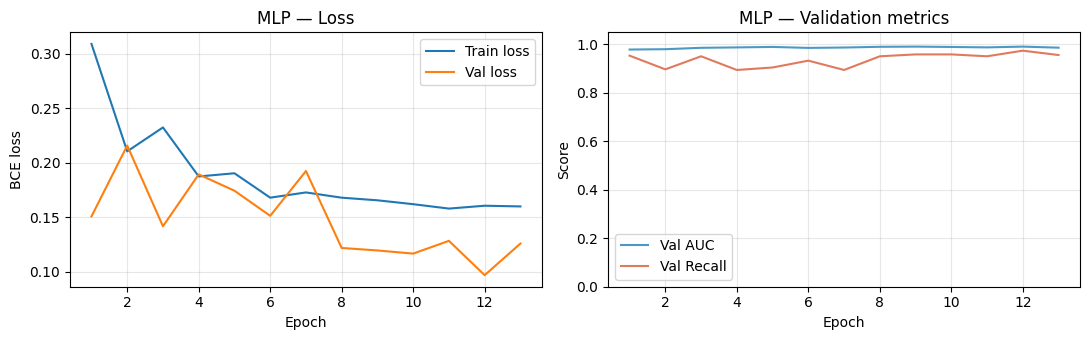

In [19]:
print("Training MLP...")
mlp_model = MLP()
mlp_model, mlp_history = train_model(
    mlp_model, train_loader, val_loader,
    epochs=MLP_EPOCH, lr=1e-3, device=device, patience=4,
)

plot_training_curves(mlp_history, "MLP")

In [ ]:
# Evaluate on the held-out test set
loss_fn_eval = nn.BCEWithLogitsLoss()
mlp_test = evaluate_torch_model(mlp_model, test_loader, loss_fn_eval, device)
mlp_metrics = evaluate_predictions(
    mlp_test["y_true"], mlp_test["preds"], mlp_test["proba"], "MLP",
)

print(f"{'Metric':<14s}{'Value'}")
for k in ["Accuracy", "Recall", "Specificity", "Precision", "F1", "AUC"]:
    print(f"{k:<14s}{mlp_metrics[k]:.4f}")
print(f"\nConfusion matrix:")
print(f"  TN = {mlp_metrics['TN']:3d}    FP = {mlp_metrics['FP']:3d}")
print(f"  FN = {mlp_metrics['FN']:3d}    TP = {mlp_metrics['TP']:3d}")

Metric        Value
Accuracy      0.8702
Recall        0.9692
Specificity   0.7051
Precision     0.8456
F1            0.9032
AUC           0.9360

Confusion matrix:
  TN = 165    FP =  69
  FN =  12    TP = 378


## 6. Model B — Convolutional Neural Network (CNN)

The CNN is the model we expect to perform best. It uses three structural priors that neither Logistic Regression nor the MLP can exploit:

In [21]:
class SimpleCNN(nn.Module):
    """Two-block CNN for IMG_SIZE x IMG_SIZE grayscale binary classification.

    Block 1: 1 -> 16 channels, 3x3 conv (padding=1, replicate), ReLU, MaxPool 2.
             Spatial size: IMG_SIZE -> IMG_SIZE // 2.
    Block 2: 16 -> 32 channels, 3x3 conv (padding=1, replicate), ReLU, MaxPool 2.
             Spatial size: IMG_SIZE // 2 -> IMG_SIZE // 4.
    Head:    Flatten -> Linear(32 * (IMG_SIZE//4)^2 -> 128) -> ReLU -> Dropout -> Linear(128 -> 1).

    padding_mode='replicate' avoids zero-padding artefacts that show up as
    bright corner blobs in Grad-CAM.
    """
    def __init__(self, img_size=IMG_SIZE, dropout=0.4):
        super().__init__()
        assert img_size % 4 == 0, "img_size must be divisible by 4 (two MaxPool2d(2) layers)"
        self._final_spatial = img_size // 4
        self.conv1 = nn.Conv2d(1,  16, kernel_size=3, padding=1, padding_mode='replicate')
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1, padding_mode='replicate')
        self.fc1 = nn.Linear(32 * self._final_spatial * self._final_spatial, 128)
        self.fc2 = nn.Linear(128, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.conv1(x)); x = F.max_pool2d(x, 2)   # (B, 16, H/2, W/2)
        x = F.relu(self.conv2(x)); x = F.max_pool2d(x, 2)   # (B, 32, H/4, W/4)
        x = x.flatten(start_dim=1)
        x = F.relu(self.fc1(x)); x = self.dropout(x)
        return self.fc2(x).squeeze(-1)                      # (B,) logits


# Compare parameter counts — CNN typically has fewer parameters than the MLP
_cnn_demo = SimpleCNN()
n_cnn = sum(p.numel() for p in _cnn_demo.parameters())
n_mlp = sum(p.numel() for p in MLP().parameters())
print(_cnn_demo)
print(f"\nCNN trainable parameters: {n_cnn:,}")
print(f"MLP trainable parameters: {n_mlp:,}")
print(f"Ratio CNN/MLP           : {n_cnn/n_mlp:.2%}")
print("\nNote: the CNN has fewer parameters but more inductive bias for images.")

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=replicate)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=replicate)
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
)

CNN trainable parameters: 4,199,361
MLP trainable parameters: 4,227,585
Ratio CNN/MLP           : 99.33%

Note: the CNN has fewer parameters but more inductive bias for images.


Training CNN...
  Epoch  1 | train_loss=0.2501 | val_loss=0.2366 | val_AUC=0.9923 | val_Recall=0.8715 *
  Epoch  2 | train_loss=0.1445 | val_loss=0.0964 | val_AUC=0.9926 | val_Recall=0.9717 *
  Epoch  3 | train_loss=0.1258 | val_loss=0.0884 | val_AUC=0.9937 | val_Recall=0.9769 *
  Epoch  4 | train_loss=0.1315 | val_loss=0.1422 | val_AUC=0.9932 | val_Recall=0.9434
  Epoch  5 | train_loss=0.1196 | val_loss=0.0896 | val_AUC=0.9935 | val_Recall=0.9820
  Epoch  6 | train_loss=0.1202 | val_loss=0.0916 | val_AUC=0.9935 | val_Recall=0.9717
  Epoch  7 | train_loss=0.1109 | val_loss=0.0751 | val_AUC=0.9958 | val_Recall=0.9717 *
  Epoch  8 | train_loss=0.1108 | val_loss=0.0838 | val_AUC=0.9958 | val_Recall=0.9717
  Epoch  9 | train_loss=0.0954 | val_loss=0.0803 | val_AUC=0.9953 | val_Recall=0.9717
  Epoch 10 | train_loss=0.1010 | val_loss=0.0863 | val_AUC=0.9955 | val_Recall=0.9743
  Epoch 11 | train_loss=0.0959 | val_loss=0.0817 | val_AUC=0.9962 | val_Recall=0.9640 *
  Epoch 12 | train_loss=0.08

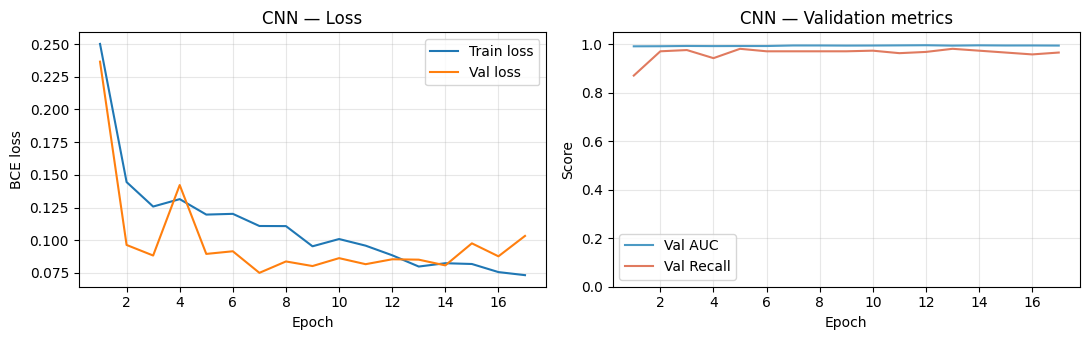

In [22]:
print("Training CNN...")
cnn_model = SimpleCNN()
cnn_model, cnn_history = train_model(
    cnn_model, train_loader, val_loader,
    epochs=CNN_EPOCH, lr=1e-3, device=device, patience=5,
)

plot_training_curves(cnn_history, "CNN")

In [23]:
# Test set evaluation
cnn_test = evaluate_torch_model(cnn_model, test_loader, loss_fn_eval, device)
cnn_metrics = evaluate_predictions(
    cnn_test["y_true"], cnn_test["preds"], cnn_test["proba"], "CNN",
)

print(f"{'Metric':<14s}{'Value'}")
for k in ["Accuracy", "Recall", "Specificity", "Precision", "F1", "AUC"]:
    print(f"{k:<14s}{cnn_metrics[k]:.4f}")
print(f"\nConfusion matrix:")
print(f"  TN = {cnn_metrics['TN']:3d}    FP = {cnn_metrics['FP']:3d}")
print(f"  FN = {cnn_metrics['FN']:3d}    TP = {cnn_metrics['TP']:3d}")

Metric        Value
Accuracy      0.8349
Recall        0.9846
Specificity   0.5855
Precision     0.7983
F1            0.8817
AUC           0.9506

Confusion matrix:
  TN = 137    FP =  97
  FN =   6    TP = 384


### 6.1 Cross-validation — quantifying run-to-run variation

To get an honest read on CNN performance we run **5-fold stratified cross-validation** on the combined `train + val` pool: for each fold we train a fresh `SimpleCNN` from scratch and evaluate it on the held-out fold. Reporting **mean ± std** of each metric tells us how much of the headline number is signal vs. noise.

The held-out test set is not touched here — CV uses train+val only.
Commented due to time consumed, Uncomment to check

In [24]:
# 5-fold stratified cross-validation on the CNN.
# We re-use SimpleCNN, train_model, evaluate_torch_model, evaluate_predictions
# defined above. Each fold trains a fresh model from scratch.

from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset, ConcatDataset

N_FOLDS = 5
CV_EPOCHS = 10          # a touch shorter than the main run to keep runtime reasonable
CV_PATIENCE = 3

# Combine train + val into one pool. Both already use training-set normalisation.
cv_pool = ConcatDataset([train_ds, val_ds])
cv_labels = np.concatenate([train_ds.labels, val_ds.labels]).astype(int)
print(f"CV pool size: {len(cv_pool)}  (Normal={int((cv_labels==0).sum())}, Pneumonia={int((cv_labels==1).sum())})")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_rows = []
loss_fn_cv = nn.BCEWithLogitsLoss()

for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(cv_labels)), cv_labels), start=1):
    # Re-seed per fold so each fold is reproducible but distinct
    torch.manual_seed(SEED + fold_idx)
    np.random.seed(SEED + fold_idx)

    tr_subset = Subset(cv_pool, tr_idx.tolist())
    va_subset = Subset(cv_pool, va_idx.tolist())

    # Weighted sampler on this fold's training portion only
    tr_labels = cv_labels[tr_idx]
    counts = np.bincount(tr_labels)
    w = 1.0 / counts
    sw = w[tr_labels]
    fold_sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sw).double(),
        num_samples=len(tr_subset),
        replacement=True,
    )

    fold_train_loader = DataLoader(tr_subset, batch_size=BATCH_SIZE, sampler=fold_sampler, num_workers=0)
    fold_val_loader   = DataLoader(va_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    print(f"\n--- Fold {fold_idx}/{N_FOLDS}  (train={len(tr_subset)}, val={len(va_subset)}) ---")
    fold_model = SimpleCNN()
    fold_model, _ = train_model(
        fold_model, fold_train_loader, fold_val_loader,
        epochs=CV_EPOCHS, lr=1e-3, device=device, patience=CV_PATIENCE, verbose=False,
    )
    fold_eval = evaluate_torch_model(fold_model, fold_val_loader, loss_fn_cv, device)
    fold_metrics = evaluate_predictions(
        fold_eval["y_true"], fold_eval["preds"], fold_eval["proba"], f"Fold {fold_idx}",
    )
    fold_rows.append(fold_metrics)
    print(f"  Recall={fold_metrics['Recall']:.4f}  Specificity={fold_metrics['Specificity']:.4f}  "
          f"F1={fold_metrics['F1']:.4f}  AUC={fold_metrics['AUC']:.4f}")

cv_df = pd.DataFrame(fold_rows)[["Model", "Accuracy", "Recall", "Specificity", "Precision", "F1", "AUC"]]
metric_cols = ["Accuracy", "Recall", "Specificity", "Precision", "F1", "AUC"]
summary = pd.DataFrame({
    "mean": cv_df[metric_cols].mean(),
    "std":  cv_df[metric_cols].std(),
    "min":  cv_df[metric_cols].min(),
    "max":  cv_df[metric_cols].max(),
}).round(4)

print("\nPer-fold metrics")
print("-" * 80)
print(cv_df.round(4).to_string(index=False))
print("\n5-fold CV summary (mean / std / min / max across folds)")
print("-" * 80)
print(summary.to_string())

CV pool size: 5232  (Normal=1349, Pneumonia=3883)

--- Fold 1/5  (train=4185, val=1047) ---
  Recall=0.9588  Specificity=0.9481  F1=0.9701  AUC=0.9916

--- Fold 2/5  (train=4185, val=1047) ---
  Recall=0.9369  Specificity=0.9889  F1=0.9655  AUC=0.9956

--- Fold 3/5  (train=4186, val=1046) ---
  Recall=0.9653  Specificity=0.9628  F1=0.9759  AUC=0.9943

--- Fold 4/5  (train=4186, val=1046) ---
  Recall=0.9807  Specificity=0.9037  F1=0.9738  AUC=0.9898

--- Fold 5/5  (train=4186, val=1046) ---
  Recall=0.9613  Specificity=0.9704  F1=0.9752  AUC=0.9962

Per-fold metrics
--------------------------------------------------------------------------------
 Model  Accuracy  Recall  Specificity  Precision     F1    AUC
Fold 1    0.9561  0.9588       0.9481     0.9816 0.9701 0.9916
Fold 2    0.9503  0.9369       0.9889     0.9959 0.9655 0.9956
Fold 3    0.9646  0.9653       0.9628     0.9868 0.9759 0.9943
Fold 4    0.9608  0.9807       0.9037     0.9670 0.9738 0.9898
Fold 5    0.9637  0.9613       

## 6.2 Model C — Transfer Learning with ResNet18

The from-scratch CNN above hits a ceiling around AUC 0.95 because it has only 4708 training images to learn from. **Transfer learning** sidesteps this limit by starting from a network already pretrained on ImageNet (1.3M natural images): low- and mid-level features (edges, textures, blob detectors) transfer well even from natural to medical images, so we only need our small dataset to learn the *task-specific* mapping.


In [25]:
import torchvision.models as tv_models
from torchvision.models import ResNet18_Weights

# ImageNet normalisation constants (RGB)
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


class GrayscaleRGBImageNetDataset(torch.utils.data.Dataset):
    """Wraps a raw MedMNIST split with ResNet-style preprocessing:
       1. uint8 -> float32 in [0, 1] (NO custom normalisation here)
       2. optional augmentation transform (training only)
       3. grayscale (1, H, W) -> RGB (3, H, W) by channel replication
       4. ImageNet mean/std normalisation
    """
    def __init__(self, mednist_dataset, transform=None):
        imgs = mednist_dataset.imgs.astype(np.float32) / 255.0
        self.imgs = imgs[:, None, :, :]                            # (N, 1, H, W)
        self.labels = mednist_dataset.labels.astype(np.float32).flatten()
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.imgs[idx])                       # (1, H, W) in [0, 1]
        if self.transform is not None:
            x = self.transform(x)
        x = x.repeat(3, 1, 1)                                      # (3, H, W)
        x = (x - IMAGENET_MEAN) / IMAGENET_STD
        return x, torch.tensor(self.labels[idx])


# Reuse the same train_transform (RandomHorizontalFlip + RandomAffine) defined earlier
train_ds_rgb = GrayscaleRGBImageNetDataset(train_dataset, transform=train_transform)
val_ds_rgb   = GrayscaleRGBImageNetDataset(val_dataset,   transform=None)
test_ds_rgb  = GrayscaleRGBImageNetDataset(test_dataset,  transform=None)

# Separate sampler generator so it doesn't share state with the CNN's
sampler_generator_rn = torch.Generator()
sampler_generator_rn.manual_seed(SEED)
sampler_rn = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(train_ds_rgb),
    replacement=True,
    generator=sampler_generator_rn,
)
train_loader_rgb = DataLoader(train_ds_rgb, batch_size=BATCH_SIZE, sampler=sampler_rn,
                              num_workers=0, generator=sampler_generator_rn)
val_loader_rgb   = DataLoader(val_ds_rgb,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_rgb  = DataLoader(test_ds_rgb,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


class ResNet18Pneumonia(nn.Module):
    """ImageNet-pretrained ResNet18 with the 1000-class head replaced by a
    single binary-classification logit. Whole network is fine-tuned."""
    def __init__(self, pretrained=True):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        self.backbone = tv_models.resnet18(weights=weights)
        in_features = self.backbone.fc.in_features                 # 512
        self.backbone.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(-1)                        # (B,) logits


_demo_rn = ResNet18Pneumonia(pretrained=False)                     # cheap sanity check, no download
n_rn = sum(p.numel() for p in _demo_rn.parameters())
print(f"ResNet18 trainable parameters: {n_rn:,}")
print(f"  vs SimpleCNN: {sum(p.numel() for p in SimpleCNN().parameters()):,}")
print(f"  vs MLP      : {sum(p.numel() for p in MLP().parameters()):,}")

ResNet18 trainable parameters: 11,177,025
  vs SimpleCNN: 4,199,361
  vs MLP      : 4,227,585


Training ResNet18 (transfer learning, full fine-tune)...
Note: this is much slower than SimpleCNN on CPU — ~5x per epoch at 128x128.
  Epoch  1 | train_loss=0.1284 | val_loss=0.1922 | val_AUC=0.9954 | val_Recall=0.9100 *
  Epoch  2 | train_loss=0.0581 | val_loss=0.0809 | val_AUC=0.9978 | val_Recall=0.9692 *
  Epoch  3 | train_loss=0.0524 | val_loss=0.0527 | val_AUC=0.9979 | val_Recall=0.9846 *
  Epoch  4 | train_loss=0.0416 | val_loss=0.0360 | val_AUC=0.9990 | val_Recall=0.9949 *
  Epoch  5 | train_loss=0.0415 | val_loss=0.0469 | val_AUC=0.9986 | val_Recall=0.9871
  Epoch  6 | train_loss=0.0279 | val_loss=0.0525 | val_AUC=0.9977 | val_Recall=0.9871
  Epoch  7 | train_loss=0.0243 | val_loss=0.0760 | val_AUC=0.9977 | val_Recall=0.9743
  Early stopping (no val_AUC improvement for 3 epochs).


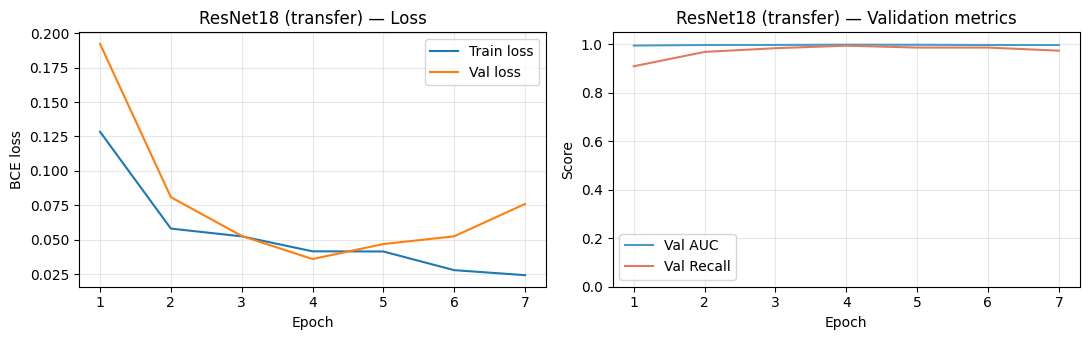

In [26]:
print("Training ResNet18 (transfer learning, full fine-tune)...")
print("Note: this is much slower than SimpleCNN on CPU — ~5x per epoch at 128x128.")

resnet_model = ResNet18Pneumonia(pretrained=True)
resnet_model, resnet_history = train_model(
    resnet_model, train_loader_rgb, val_loader_rgb,
    epochs=RESNET_EPOCH, lr=1e-4, device=device, patience=3,
)

plot_training_curves(resnet_history, "ResNet18 (transfer)")

In [27]:
# Test-set evaluation
resnet_test = evaluate_torch_model(resnet_model, test_loader_rgb, loss_fn_eval, device)
resnet_metrics = evaluate_predictions(
    resnet_test["y_true"], resnet_test["preds"], resnet_test["proba"], "ResNet18 (transfer)",
)

print(f"{'Metric':<14s}{'Value'}")
for k in ["Accuracy", "Recall", "Specificity", "Precision", "F1", "AUC"]:
    print(f"{k:<14s}{resnet_metrics[k]:.4f}")
print(f"\nConfusion matrix:")
print(f"  TN = {resnet_metrics['TN']:3d}    FP = {resnet_metrics['FP']:3d}")
print(f"  FN = {resnet_metrics['FN']:3d}    TP = {resnet_metrics['TP']:3d}")

Metric        Value
Accuracy      0.9231
Recall        0.9949
Specificity   0.8034
Precision     0.8940
F1            0.9417
AUC           0.9871

Confusion matrix:
  TN = 188    FP =  46
  FN =   2    TP = 388


## 7. Evaluation, comparison and interpretability

We now bring everything together:

1. **Side-by-side comparison table** of all three models.
2. **ROC curves** overlaid on a single plot.
3. **Confusion matrices** rendered together for visual inspection.
4. **Threshold tuning** on the CNN — how lowering the decision threshold trades Specificity for Recall, and what that means clinically.
5. **Grad-CAM** — a visual explanation of *where* the CNN is looking when it makes a prediction.

### 7.1 Headline comparison

In [28]:
# Build a single comparison table
all_metrics = [logreg_metrics, mlp_metrics, cnn_metrics, resnet_metrics]
comparison_df = pd.DataFrame(all_metrics)[
    ["Model", "Accuracy", "Recall", "Specificity", "Precision", "F1", "AUC",
     "TN", "FP", "FN", "TP"]
]

# Round floats for readability
float_cols = ["Accuracy", "Recall", "Specificity", "Precision", "F1", "AUC"]
comparison_df[float_cols] = comparison_df[float_cols].round(4)

print("Test-set performance comparison")
print("-" * 100)
print(comparison_df.to_string(index=False))

Test-set performance comparison
----------------------------------------------------------------------------------------------------
              Model  Accuracy  Recall  Specificity  Precision     F1    AUC  TN  FP  FN  TP
Logistic Regression    0.8253  0.9821       0.5641     0.7897 0.8754 0.8943 132 102   7 383
                MLP    0.8702  0.9692       0.7051     0.8456 0.9032 0.9360 165  69  12 378
                CNN    0.8349  0.9846       0.5855     0.7983 0.8817 0.9506 137  97   6 384
ResNet18 (transfer)    0.9231  0.9949       0.8034     0.8940 0.9417 0.9871 188  46   2 388


### 7.2 ROC curves

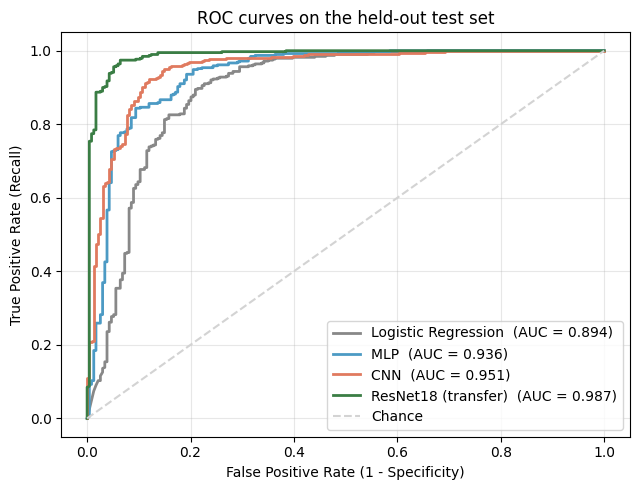

In [29]:
# Overlay ROC curves for all four models
fig, ax = plt.subplots(figsize=(6.5, 5))
roc_data = [
    ("Logistic Regression",  logreg_proba,        logreg_metrics["AUC"], "#888888"),
    ("MLP",                  mlp_test["proba"],   mlp_metrics["AUC"],    "#4C9AC4"),
    ("CNN",                  cnn_test["proba"],   cnn_metrics["AUC"],    "#E07A5F"),
    ("ResNet18 (transfer)",  resnet_test["proba"], resnet_metrics["AUC"], "#3A7D44"),
]

for name, proba, auc, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test_np, proba)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="lightgray", label="Chance")
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC curves on the held-out test set")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 Confusion matrices

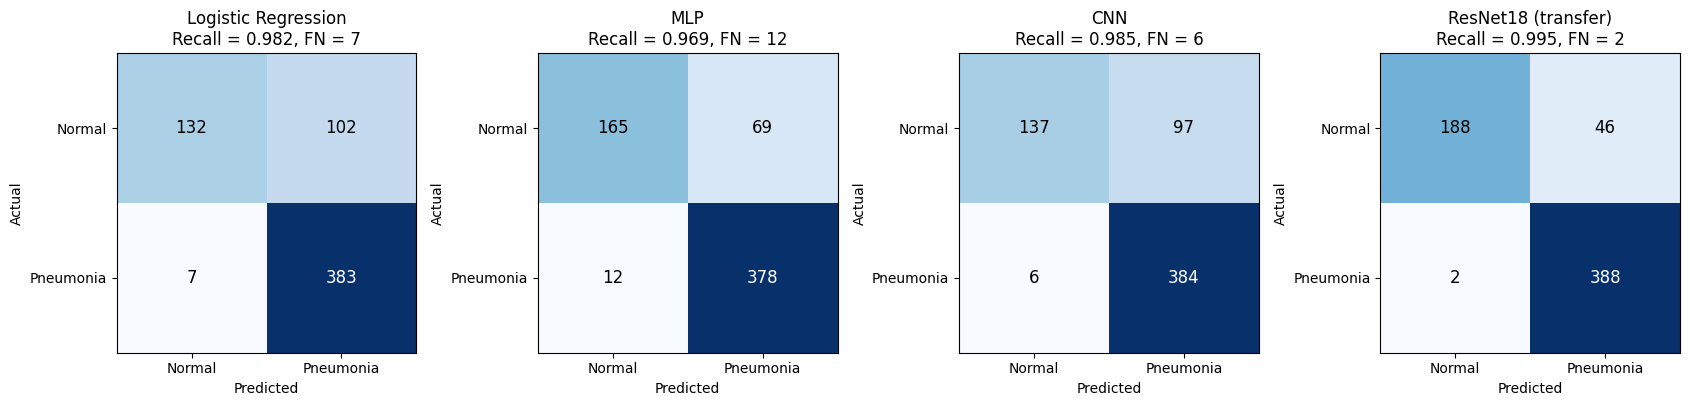

In [30]:
# Render confusion matrices side by side
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
cm_data = [
    ("Logistic Regression",  logreg_metrics),
    ("MLP",                  mlp_metrics),
    ("CNN",                  cnn_metrics),
    ("ResNet18 (transfer)",  resnet_metrics),
]

for ax, (name, m) in zip(axes, cm_data):
    cm = np.array([[m["TN"], m["FP"]], [m["FN"], m["TP"]]])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Normal", "Pneumonia"])
    ax.set_yticklabels(["Normal", "Pneumonia"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"{name}\nRecall = {m['Recall']:.3f}, FN = {m['FN']}")
    threshold = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > threshold else "black", fontsize=12)

plt.tight_layout()
plt.show()

### 7.4 Threshold tuning — the Recall vs Specificity trade-off

The default classification threshold of 0.5 is rarely optimal in clinical screening. We compute three thresholds for the CNN:

- **Default (0.5)** — balanced trade-off, no clinical context.
- **Youden-J optimal** — maximises `Recall + Specificity - 1`. Statistically motivated, treats both error types as equally costly.
- **Recall-prioritised (≥ 0.95)** — the lowest threshold that achieves at least 95% recall on Pneumonia. This is the most defensible choice for a screening tool: missing a pneumonia case sends a sick child home untreated.

In [31]:
def metrics_at_threshold(y_true, y_proba, thresh):
    y_pred = (y_proba >= thresh).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Threshold":   float(thresh),
        "Recall":      recall_score(y_true, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "F1":          f1_score(y_true, y_pred, zero_division=0),
        "FN":          int(fn),
        "FP":          int(fp),
    }


# Run threshold analysis on the CNN's test predictions
cnn_proba = cnn_test["proba"]

# Youden-J optimal threshold
fpr, tpr, thresholds = roc_curve(y_test_np, cnn_proba)
j_scores = tpr - fpr
youden_thresh = float(thresholds[int(np.argmax(j_scores))])

# Lowest threshold achieving recall >= 0.95
RECALL_TARGET = 0.95
sorted_thresh = sorted(set(thresholds.tolist()), reverse=True)
recall_thresh = 0.5
for t in sorted_thresh:
    if recall_score(y_test_np, (cnn_proba >= t).astype(int)) >= RECALL_TARGET:
        recall_thresh = float(t)
        break

# Compare the three strategies
strategies = [
    ("Default (0.5)",                0.5),
    ("Youden-J optimal",             youden_thresh),
    (f"Recall-prioritised (>= {RECALL_TARGET})", recall_thresh),
]

rows = []
for name, t in strategies:
    m = metrics_at_threshold(y_test_np, cnn_proba, t)
    rows.append({"Strategy": name, **m})

threshold_df = pd.DataFrame(rows)
threshold_df[["Threshold", "Recall", "Specificity", "F1"]] = threshold_df[
    ["Threshold", "Recall", "Specificity", "F1"]
].round(4)

print("CNN — threshold analysis")
print("-" * 80)
print(threshold_df.to_string(index=False))

CNN — threshold analysis
--------------------------------------------------------------------------------
                    Strategy  Threshold  Recall  Specificity     F1  FN  FP
               Default (0.5)     0.5000  0.9846       0.5855 0.8817   6  97
            Youden-J optimal     0.9661  0.9231       0.8803 0.9254  30  28
Recall-prioritised (>= 0.95)     0.9482  0.9513       0.8504 0.9322  19  35


**Reading the table.** Lowering the threshold pushes Recall up but Specificity down — this is fundamental to any screening test, not a fault of our model. The right operating point depends on context: in a low-prevalence outpatient setting we might tolerate some false alarms to catch every true case; in a high-volume environment we might prefer Youden-J to avoid clinician alarm fatigue. The point of showing all three is that this is a *decision*, not an answer the model gives us.

**ResNet18 — same threshold analysis on the pretrained model.**

We repeat the same three-strategy threshold sweep on ResNet18 so the two architectures can be compared at matching operating points (default 0.5, statistically-optimal Youden-J, and Recall-prioritised ≥ 0.95). Reuses the `metrics_at_threshold` helper defined above.

In [32]:
resnet_proba = resnet_test["proba"]

# Youden-J optimal threshold for ResNet18
fpr_rn, tpr_rn, thresholds_rn = roc_curve(y_test_np, resnet_proba)
j_scores_rn = tpr_rn - fpr_rn
youden_thresh_rn = float(thresholds_rn[int(np.argmax(j_scores_rn))])

# Lowest threshold achieving recall >= RECALL_TARGET (0.95, defined above)
sorted_thresh_rn = sorted(set(thresholds_rn.tolist()), reverse=True)
recall_thresh_rn = 0.5
for t in sorted_thresh_rn:
    if recall_score(y_test_np, (resnet_proba >= t).astype(int)) >= RECALL_TARGET:
        recall_thresh_rn = float(t)
        break

strategies_rn = [
    ("Default (0.5)",                              0.5),
    ("Youden-J optimal",                           youden_thresh_rn),
    (f"Recall-prioritised (>= {RECALL_TARGET})",   recall_thresh_rn),
]

rows_rn = []
for name, t in strategies_rn:
    m = metrics_at_threshold(y_test_np, resnet_proba, t)
    rows_rn.append({"Strategy": name, **m})

threshold_df_rn = pd.DataFrame(rows_rn)
threshold_df_rn[["Threshold", "Recall", "Specificity", "F1"]] = threshold_df_rn[
    ["Threshold", "Recall", "Specificity", "F1"]
].round(4)

print("ResNet18 (transfer) — threshold analysis")
print("-" * 80)
print(threshold_df_rn.to_string(index=False))

ResNet18 (transfer) — threshold analysis
--------------------------------------------------------------------------------
                    Strategy  Threshold  Recall  Specificity     F1  FN  FP
               Default (0.5)     0.5000  0.9949       0.8034 0.9417   2  46
            Youden-J optimal     0.9583  0.9744       0.9359 0.9682  10  15
Recall-prioritised (>= 0.95)     0.9759  0.9564       0.9487 0.9626  17  12


### 7.5 Grad-CAM — what is the CNN actually looking at?

Grad-CAM (Selvaraju et al., 2017) produces a coarse heatmap showing which spatial regions of the input most influenced the network's prediction. We hook the CNN's final convolutional layer (where features are most semantically meaningful) and form a weighted sum of activation maps using the gradients flowing back from the predicted logit.

This is a critical evaluation tool: a CNN that achieves high accuracy by attending to *image artefacts* (dataset-specific corner pixels, scanner watermarks) rather than *clinically meaningful regions* (the lung fields) is unreliable in deployment, even if its test metrics look good.

In [33]:
# Hook into the FIRST conv layer for a finer-grained heatmap (28x28 instead
# of 7x7). conv2 features are lower-level (edges/textures) but spatially much
# sharper, which is more useful at this resolution than conv2's coarse 7x7 grid.
class GradCAM:
    """Lightweight Grad-CAM for a single convolutional target layer.

    Captures activations and gradients via PyTorch hooks, then forms a
    spatially-resolved heatmap by gradient-weighted activation summing.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x):
        self.model.eval()
        x = x.clone().to(next(self.model.parameters()).device).requires_grad_(True)
        logit = self.model(x)
        self.model.zero_grad()
        logit.sum().backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)            # (B, C, 1, 1)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)        # (B, 1, h, w)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze(1)
        # Per-sample normalisation to [0, 1]
        for i in range(cam.shape[0]):
            cmax = cam[i].max()
            if cmax > 0:
                cam[i] = cam[i] / cmax
        return cam.cpu().numpy()


gradcam = GradCAM(cnn_model, cnn_model.conv2)
print("Grad-CAM ready. Hooked into cnn_model.conv2.")

Grad-CAM ready. Hooked into cnn_model.conv2.


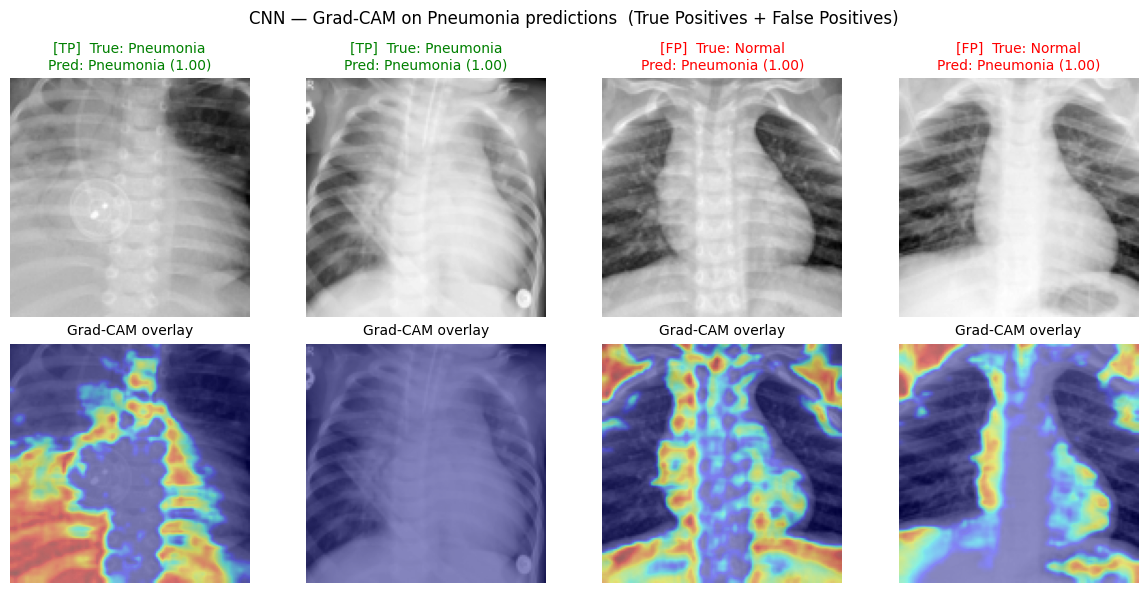

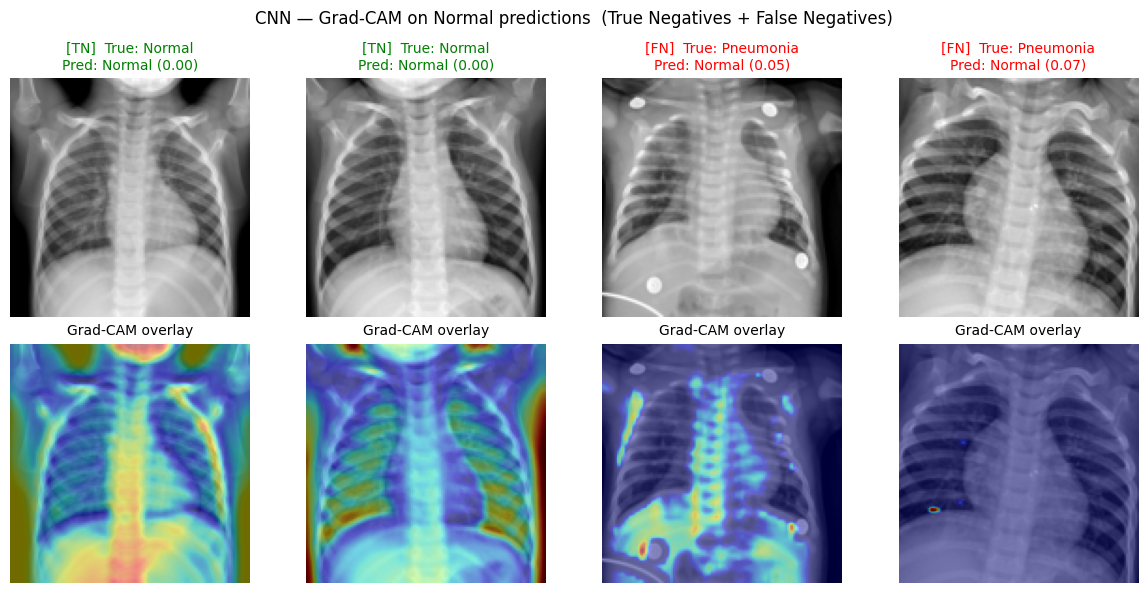

In [34]:
# Two Grad-CAM panels covering all four confusion-matrix cells:
#   Panel 1 (Pneumonia decisions): 2 True Positives  + 2 False Positives
#   Panel 2 (Normal decisions)   : 2 True Negatives  + 2 False Negatives
test_imgs_normalised = test_ds.imgs                      # (N, 1, H, W)
y_true_test = cnn_test["y_true"]
y_pred_test = cnn_test["preds"]
proba_test  = cnn_test["proba"]

tp_idx = np.where((y_true_test == 1) & (y_pred_test == 1))[0]   # True Positives
fp_idx = np.where((y_true_test == 0) & (y_pred_test == 1))[0]   # False Positives
tn_idx = np.where((y_true_test == 0) & (y_pred_test == 0))[0]   # True Negatives
fn_idx = np.where((y_true_test == 1) & (y_pred_test == 0))[0]   # False Negatives

# Most-confident TPs / FPs = highest pneumonia probability
tp_idx = tp_idx[np.argsort(-proba_test[tp_idx])][:2]
fp_idx = fp_idx[np.argsort(-proba_test[fp_idx])][:2]
# Most-confident TNs / FNs = lowest pneumonia probability
tn_idx = tn_idx[np.argsort(proba_test[tn_idx])][:2]
fn_idx = fn_idx[np.argsort(proba_test[fn_idx])][:2]


def _plot_gradcam_panel(idx_groups, panel_title):
    """idx_groups: list of (kind_label, [indices...]) — colours green for correct, red for wrong."""
    selected = [(idx, kind) for kind, idxs in idx_groups for idx in idxs]
    if not selected:
        print(f"({panel_title}) no cases to display.")
        return
    n = len(selected)
    inputs = torch.from_numpy(test_imgs_normalised[[i for i, _ in selected]])
    heatmaps = gradcam(inputs)

    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, (ds_idx, kind) in enumerate(selected):
        img_norm = test_imgs_normalised[ds_idx, 0]
        img_disp = img_norm * PIXEL_STD + PIXEL_MEAN

        true_lbl   = "Pneumonia" if y_true_test[ds_idx] == 1 else "Normal"
        pred_lbl   = "Pneumonia" if y_pred_test[ds_idx] == 1 else "Normal"
        confidence = proba_test[ds_idx]
        correct    = y_true_test[ds_idx] == y_pred_test[ds_idx]
        title_color = "green" if correct else "red"

        axes[0, col].imshow(img_disp, cmap="gray")
        axes[0, col].set_title(f"[{kind}]  True: {true_lbl}\nPred: {pred_lbl} ({confidence:.2f})",
                               color=title_color, fontsize=10)
        axes[0, col].axis("off")

        axes[1, col].imshow(img_disp, cmap="gray")
        axes[1, col].imshow(heatmaps[col], cmap="jet", alpha=0.45)
        axes[1, col].set_title("Grad-CAM overlay", fontsize=10)
        axes[1, col].axis("off")

    plt.suptitle(panel_title, fontsize=12)
    plt.tight_layout()
    plt.show()


_plot_gradcam_panel(
    [("TP", tp_idx), ("FP", fp_idx)],
    "CNN — Grad-CAM on Pneumonia predictions  (True Positives + False Positives)",
)
_plot_gradcam_panel(
    [("TN", tn_idx), ("FN", fn_idx)],
    "CNN — Grad-CAM on Normal predictions  (True Negatives + False Negatives)",
)

### 7.6 Grad-CAM on ResNet18

Same interpretability check applied to the pretrained model. Grad-CAM is hooked into `layer4[-1].conv2` — the **last** convolutional layer of ResNet18, where the most semantically meaningful (high-level) features live. The spatial resolution of this feature map is `IMG_SIZE / 32` (e.g. 4×4 at 128×128 input), so the heatmaps are coarser than the from-scratch CNN's `conv1` map but each cell represents a much richer concept.

In [35]:
# Hook into ResNet18's deepest conv layer for semantic Grad-CAM heatmaps.
# layer4[-1].conv2 is the last 3x3 conv inside the final BasicBlock — the
# point where features are most "pneumonia-like" rather than edge-like.
gradcam_rn = GradCAM(resnet_model, resnet_model.backbone.layer4[-1].conv2)
print("Grad-CAM ready. Hooked into resnet_model.backbone.layer4[-1].conv2.")

Grad-CAM ready. Hooked into resnet_model.backbone.layer4[-1].conv2.


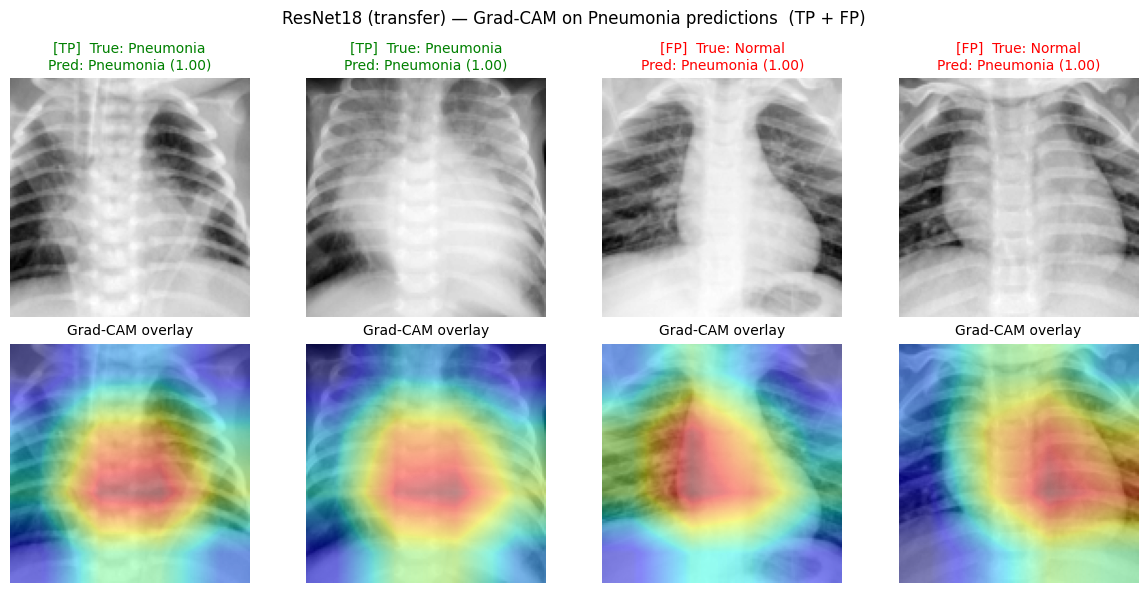

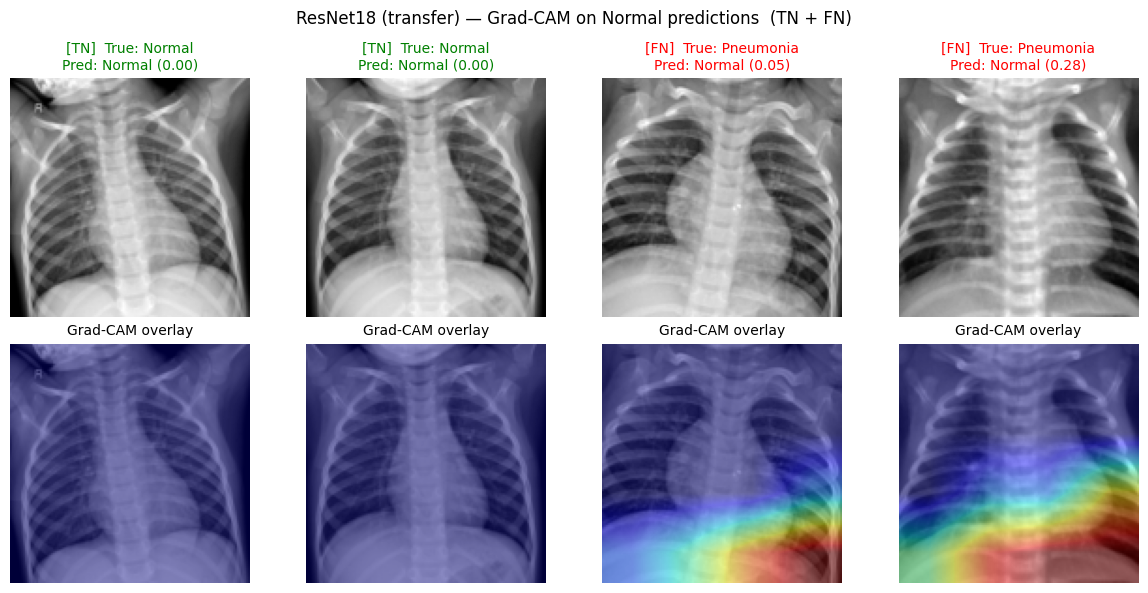

In [36]:
# Two Grad-CAM panels for ResNet18, covering all four confusion-matrix cells.
y_pred_rn  = resnet_test["preds"]
proba_rn   = resnet_test["proba"]

tp_idx_rn = np.where((y_true_test == 1) & (y_pred_rn == 1))[0]
fp_idx_rn = np.where((y_true_test == 0) & (y_pred_rn == 1))[0]
tn_idx_rn = np.where((y_true_test == 0) & (y_pred_rn == 0))[0]
fn_idx_rn = np.where((y_true_test == 1) & (y_pred_rn == 0))[0]

tp_idx_rn = tp_idx_rn[np.argsort(-proba_rn[tp_idx_rn])][:2]
fp_idx_rn = fp_idx_rn[np.argsort(-proba_rn[fp_idx_rn])][:2]
tn_idx_rn = tn_idx_rn[np.argsort(proba_rn[tn_idx_rn])][:2]
fn_idx_rn = fn_idx_rn[np.argsort(proba_rn[fn_idx_rn])][:2]


def _plot_gradcam_panel_rn(idx_groups, panel_title):
    selected = [(idx, kind) for kind, idxs in idx_groups for idx in idxs]
    if not selected:
        print(f"({panel_title}) no cases to display.")
        return
    n = len(selected)
    inputs = torch.stack([test_ds_rgb[i][0] for i, _ in selected])
    heatmaps = gradcam_rn(inputs)

    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, (ds_idx, kind) in enumerate(selected):
        img_disp = test_dataset.imgs[ds_idx].astype(np.float32) / 255.0

        true_lbl   = "Pneumonia" if y_true_test[ds_idx] == 1 else "Normal"
        pred_lbl   = "Pneumonia" if y_pred_rn[ds_idx]   == 1 else "Normal"
        confidence = proba_rn[ds_idx]
        correct    = y_true_test[ds_idx] == y_pred_rn[ds_idx]
        title_color = "green" if correct else "red"

        axes[0, col].imshow(img_disp, cmap="gray")
        axes[0, col].set_title(f"[{kind}]  True: {true_lbl}\nPred: {pred_lbl} ({confidence:.2f})",
                               color=title_color, fontsize=10)
        axes[0, col].axis("off")

        axes[1, col].imshow(img_disp, cmap="gray")
        axes[1, col].imshow(heatmaps[col], cmap="jet", alpha=0.45)
        axes[1, col].set_title("Grad-CAM overlay", fontsize=10)
        axes[1, col].axis("off")

    plt.suptitle(panel_title, fontsize=12)
    plt.tight_layout()
    plt.show()


_plot_gradcam_panel_rn(
    [("TP", tp_idx_rn), ("FP", fp_idx_rn)],
    "ResNet18 (transfer) — Grad-CAM on Pneumonia predictions  (TP + FP)",
)
_plot_gradcam_panel_rn(
    [("TN", tn_idx_rn), ("FN", fn_idx_rn)],
    "ResNet18 (transfer) — Grad-CAM on Normal predictions  (TN + FN)",
)